# Real Dataset Model Testing — Safety-Area Bound

This notebook verifies that each safety-area image subset is passed only to its matching model checkpoint.

Correct binding:

- `ConvBelt` data → `model_ConvBelt_64.pt`
- `PLeft` data → `model_PLeft_64.pt`
- `PRight` data → `model_PRight_64.pt`
- `RoboArm` data → `model_RoboArm_64.pt`

The notebook uses `configs/config.yaml` to resolve dataset paths and your actual config structure where `datasets.available` is a list of dictionaries.

It first shows the exact images that will be passed to the model, then runs reconstruction and anomaly-map visualization.

In [1]:
# ============================================================
# Imports
# ============================================================
import os
import re
import sys
import random
from pathlib import Path
from pprint import pprint

import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

plt.rcParams["figure.dpi"] = 120

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", hasattr(torch.backends, "mps") and torch.backends.mps.is_available())

PyTorch: 2.5.1
CUDA available: True
MPS available: False


In [2]:
# ============================================================
# Project root detection
# ============================================================
def find_project_root(start=None):
    if start is None:
        start = Path.cwd()
    start = Path(start).resolve()

    for p in [start] + list(start.parents):
        if (p / "configs" / "config.yaml").exists():
            return p
    return start

PROJECT_ROOT = find_project_root()
print("PROJECT_ROOT:", PROJECT_ROOT)

for p in [PROJECT_ROOT, PROJECT_ROOT / "scripts"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

PROJECT_ROOT: E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold


In [3]:
from pathlib import Path
from collections import Counter
import os

def inspect_dataset_structure(root, max_depth=4):
    root = Path(root)

    print("=" * 100)
    print("DATASET STRUCTURE")
    print("=" * 100)
    print("Root:", root)

    if not root.exists():
        print("❌ Path does not exist")
        return

    for p in sorted(root.rglob("*")):
        try:
            depth = len(p.relative_to(root).parts)
        except:
            continue

        if depth <= max_depth and p.is_dir():
            print(p.relative_to(root))


def count_images(folder):
    exts = {".png", ".jpg", ".jpeg", ".bmp"}
    return sum(
        1 for p in Path(folder).rglob("*")
        if p.suffix.lower() in exts
    )


def summarize_dataset(root):
    root = Path(root)

    print("\n")
    print("=" * 100)
    print("IMAGE COUNTS")
    print("=" * 100)

    for d in sorted(root.rglob("*")):
        if not d.is_dir():
            continue

        n = count_images(d)

        if n > 0:
            print(f"{d.relative_to(root)} : {n}")

In [4]:
# ============================================================
# User settings
# ============================================================
# Must match the name in config.yaml: MVtec, Robotics_Hazards, Cobots_Synthetic
DATASET_NAME,SAFETY_AREA = "Cobots_Synthetic", "PLeft"
# DATASET_NAME,SAFETY_AREA = "Cobots_Synthetic", "PRight"
# DATASET_NAME,SAFETY_AREA = "Cobots_Synthetic", "RoboArm"
# DATASET_NAME,SAFETY_AREA = "Cobots_Synthetic", "ConvBelt"


# For Cobots_Synthetic: PLeft, PRight, RoboArm, ConvBelt
# For Robotics_Hazards: corridor
# For MVtec: object name such as hazelnut, bottle, cable, etc.

# DATASET_NAME,SAFETY_AREA = "Robotics_Hazards", "corridor"

# DATASET_NAME,SAFETY_AREA = "MVtec", "hazelnut"


LATENT_DIMS = 64
IMAGE_SIZE = 128

# Optional overrides. Keep None to use config.yaml and default checkpoint layout.
DATASET_ROOT_OVERRIDE = None
MODEL_PATH_OVERRIDE = None
CHECKPOINT_ROOT_OVERRIDE = None

N_TRAIN_NORMAL = 4
N_TEST_NORMAL = 4
N_TEST_ANOMALY = 4

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

In [5]:
# ============================================================
# Device
# ============================================================
def resolve_device(device="auto"):
    if device == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    return torch.device(device)

device = resolve_device("auto")
print("Using device:", device)

Using device: cuda


## Load `config.yaml`

This parser supports your actual config format:

```yaml
datasets:
  available:
    - name: "Cobots_Synthetic"
      path: "D://DS//AD//Cobots_Synthetic"
      path_train: "D://DS//AD//Cobots_Synthetic//train"
      path_test: "D://DS//AD//Cobots_Synthetic//test"
```

In [6]:
# ============================================================
# Config parser for your actual config.yaml structure
# ============================================================
def expand_env_vars(value):
    """
    Expand environment variables in config paths.
    Supports ${VAR} and ${VAR:-default}.
    """
    if value is None:
        return None
    value = str(value)
    pattern = re.compile(r"\$\{([^}:]+)(:-([^}]*))?\}")

    def repl(match):
        var_name = match.group(1)
        default = match.group(3)
        return os.environ.get(var_name, default if default is not None else "")

    return pattern.sub(repl, value)


def load_config(project_root):
    project_root = Path(project_root)
    config_path = project_root / "configs" / "config.yaml"
    if not config_path.exists():
        raise FileNotFoundError(f"Config file not found: {config_path}")
    with open(config_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
    return config, config_path


def get_dataset_entry(config, dataset_name):
    datasets_block = config.get("datasets", {})
    available = datasets_block.get("available", [])

    if not isinstance(available, list):
        raise TypeError(
            "Expected config['datasets']['available'] to be a list of dictionaries. "
            f"Got: {type(available)}"
        )

    for item in available:
        if isinstance(item, dict) and item.get("name") == dataset_name:
            return item

    available_names = [item.get("name") for item in available if isinstance(item, dict)]
    raise KeyError(
        f"Dataset '{dataset_name}' not found.\n"
        f"Available datasets: {available_names}"
    )


def _resolve_path(value, project_root):
    value = expand_env_vars(value)
    p = Path(value)
    if not p.is_absolute():
        p = Path(project_root) / p
    return p.resolve()


def get_train_test_roots_from_config(config, dataset_name, project_root):
    entry = get_dataset_entry(config, dataset_name)

    root_value = entry.get("path", entry.get("root", None))
    if root_value is None:
        data_paths = config.get("data", {}).get("paths", {})
        root_value = data_paths.get(dataset_name, None)
    if root_value is None:
        base_dir = expand_env_vars(config.get("data", {}).get("base_dir", "."))
        root_value = str(Path(base_dir) / dataset_name)

    dataset_root = _resolve_path(root_value, project_root)

    path_train = entry.get("path_train", None)
    path_test = entry.get("path_test", None)

    train_root = _resolve_path(path_train, project_root) if path_train is not None else dataset_root / "train"
    test_root = _resolve_path(path_test, project_root) if path_test is not None else dataset_root / "test"

    return dataset_root, train_root.resolve(), test_root.resolve(), entry


config, config_path = load_config(PROJECT_ROOT)
print("Loaded config:", config_path)

print("\nAvailable datasets:")
for item in config.get("datasets", {}).get("available", []):
    if isinstance(item, dict):
        print(" -", item.get("name"), "|", item.get("description", ""))

if DATASET_ROOT_OVERRIDE is not None and str(DATASET_ROOT_OVERRIDE).strip():
    DATASET_ROOT = Path(DATASET_ROOT_OVERRIDE).resolve()
    DATASET_TRAIN_ROOT = DATASET_ROOT / "train"
    DATASET_TEST_ROOT = DATASET_ROOT / "test"
    dataset_entry = None
else:
    DATASET_ROOT, DATASET_TRAIN_ROOT, DATASET_TEST_ROOT, dataset_entry = get_train_test_roots_from_config(
        config=config,
        dataset_name=DATASET_NAME,
        project_root=PROJECT_ROOT
    )

print("\nSelected dataset:", DATASET_NAME)
print("Dataset root:", DATASET_ROOT)
print("Train root:", DATASET_TRAIN_ROOT)
print("Test root:", DATASET_TEST_ROOT)
print("\nExists:")
print("Dataset root:", DATASET_ROOT.exists())
print("Train root:", DATASET_TRAIN_ROOT.exists())
print("Test root:", DATASET_TEST_ROOT.exists())

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset root does not exist: {DATASET_ROOT}")
if not DATASET_TRAIN_ROOT.exists():
    raise FileNotFoundError(f"Train root does not exist: {DATASET_TRAIN_ROOT}")
if not DATASET_TEST_ROOT.exists():
    raise FileNotFoundError(f"Test root does not exist: {DATASET_TEST_ROOT}")

Loaded config: E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\configs\config.yaml

Available datasets:
 - MVtec | MVTec Anomaly Detection Dataset
 - Robotics_Hazards | Robotics Hazards Dataset
 - Cobots_Synthetic | DistriMuSe Synthetic Palletizing Dataset (University of Granada)

Selected dataset: Cobots_Synthetic
Dataset root: D:\DS\AD\Cobots_Synthetic
Train root: D:\DS\AD\Cobots_Synthetic\train
Test root: D:\DS\AD\Cobots_Synthetic\test

Exists:
Dataset root: True
Train root: True
Test root: True


## Resolve safety-area paths

For your Cobots Synthetic dataset, the expected structure is:

```text
train/<SAFETY_AREA>/normal
test/unexpected_person/<SAFETY_AREA>/normal
test/unexpected_person/<SAFETY_AREA>/unexpected_person
```

For `ConvBelt`, the anomaly folder may be absent; the notebook handles that safely.

In [7]:
# ============================================================
# Safety-area-specific dataset paths
# ============================================================
VALID_COBOTS_AREAS = ["PLeft", "PRight", "RoboArm", "ConvBelt"]
AREA_ALIASES = {
    "pleft": "PLeft",
    "left": "PLeft",
    "pright": "PRight",
    "right": "PRight",
    "roboarm": "RoboArm",
    "robot": "RoboArm",
    "convbelt": "ConvBelt",
    "conveyor": "ConvBelt",
    "conveyorbelt": "ConvBelt",
    "corridor": "corridor",
}


def canonicalize_area(area):
    key = str(area).replace("_", "").replace("-", "").replace(" ", "").lower()
    return AREA_ALIASES.get(key, area)


def resolve_cobots_area_paths(train_root, test_root, safety_area):
    safety_area = canonicalize_area(safety_area)
    if safety_area not in VALID_COBOTS_AREAS:
        raise ValueError(f"Invalid Cobots safety area: {safety_area}. Valid areas: {VALID_COBOTS_AREAS}")

    train_normal_root = Path(train_root) / safety_area / "normal"
    test_normal_root = Path(test_root) / "unexpected_person" / safety_area / "normal"
    test_anomaly_root = Path(test_root) / "unexpected_person" / safety_area / "unexpected_person"

    print("=" * 80)
    print("SAFETY AREA DATA BINDING")
    print("=" * 80)
    print("Dataset:", DATASET_NAME)
    print("Safety area:", safety_area)
    print("Train normal:", train_normal_root)
    print("Test normal:", test_normal_root)
    print("Test anomaly:", test_anomaly_root)

    if not train_normal_root.exists():
        raise FileNotFoundError(f"Missing train normal path: {train_normal_root}")
    if not test_normal_root.exists():
        raise FileNotFoundError(f"Missing test normal path: {test_normal_root}")

    if not test_anomaly_root.exists():
        print(f"⚠️ No anomaly folder found for {safety_area}: {test_anomaly_root}")
        test_anomaly_root = None

    return train_normal_root, test_normal_root, test_anomaly_root, safety_area


def resolve_robotics_hazards_paths(dataset_root):
    dataset_root = Path(dataset_root)

    train_normal_root = dataset_root / "train" / "normal"
    test_root = dataset_root / "test"

    anomaly_roots = [
        p for p in test_root.iterdir()
        if p.is_dir()
    ]

    print("=" * 80)
    print("ROBOTICS HAZARDS DATA BINDING")
    print("=" * 80)
    print("Train normal:", train_normal_root)
    print("Test root:", test_root)
    print("Anomaly classes:")
    for p in anomaly_roots:
        print(" -", p.name)

    assert train_normal_root.exists(), f"Missing train normal path: {train_normal_root}"
    assert test_root.exists(), f"Missing test path: {test_root}"

    return train_normal_root, None, anomaly_roots, "corridor"

def collect_robotics_hazards_samples(train_normal_root, anomaly_roots, n_normal=4, n_anomaly_per_class=1):
    train_normal = sorted(Path(train_normal_root).rglob("*.png"))

    samples = []

    for p in train_normal[:n_normal]:
        samples.append((p, "train_normal"))

    for anomaly_root in anomaly_roots:
        imgs = sorted(anomaly_root.rglob("*.png"))
        for p in imgs[:n_anomaly_per_class]:
            samples.append((p, f"anomaly_{anomaly_root.name}"))

    print("=" * 80)
    print("SAMPLE COUNTS")
    print("=" * 80)
    print("Train normal:", len(train_normal))
    for anomaly_root in anomaly_roots:
        print(f"Test anomaly [{anomaly_root.name}]:", len(list(anomaly_root.rglob('*.png'))))

    return samples


if DATASET_NAME == "Cobots_Synthetic":
    train_normal_root, test_normal_root, test_anomaly_root, CANONICAL_AREA = resolve_cobots_area_paths(
        train_root=DATASET_TRAIN_ROOT,
        test_root=DATASET_TEST_ROOT,
        safety_area=SAFETY_AREA
    )
elif DATASET_NAME == "Robotics_Hazards":
    train_normal_root, test_normal_root, test_anomaly_root, CANONICAL_AREA = resolve_robotics_hazards_paths(DATASET_ROOT)
elif DATASET_NAME == "MVtec":
    CANONICAL_AREA = SAFETY_AREA
    train_normal_root = DATASET_ROOT / CANONICAL_AREA / "train" / "good"
    test_normal_root = DATASET_ROOT / CANONICAL_AREA / "test" / "good"
    test_anomaly_root = DATASET_ROOT / CANONICAL_AREA / "test"
else:
    raise ValueError(f"Unsupported dataset: {DATASET_NAME}")

print("Resolved canonical area/object:", CANONICAL_AREA)

SAFETY AREA DATA BINDING
Dataset: Cobots_Synthetic
Safety area: PLeft
Train normal: D:\DS\AD\Cobots_Synthetic\train\PLeft\normal
Test normal: D:\DS\AD\Cobots_Synthetic\test\unexpected_person\PLeft\normal
Test anomaly: D:\DS\AD\Cobots_Synthetic\test\unexpected_person\PLeft\unexpected_person
Resolved canonical area/object: PLeft


## Resolve matching checkpoint

This cell enforces model-data binding. For Cobots Synthetic, `RoboArm` can only load `model_RoboArm_64.pt`, etc.

In [8]:
# ============================================================
# Checkpoint resolution with strict safety-area binding
# ============================================================
def infer_checkpoint_group(dataset_name):
    mapping = {
        "Cobots_Synthetic": "AD_Cobots_Synthetic",
        "Robotics_Hazards": "AD_Robotics_Hazards",
        "MVtec": "AD_MVTec",
        "AD_Cobots_Synthetic": "AD_Cobots_Synthetic",
        "AD_Robotics_Hazards": "AD_Robotics_Hazards",
        "AD_MVTec": "AD_MVTec",
    }
    return mapping.get(dataset_name, dataset_name)


def resolve_checkpoint_root(project_root, dataset_name, override=None):
    if override is not None and str(override).strip():
        return Path(override).resolve()
    return Path(project_root) / "checkpoints" / infer_checkpoint_group(dataset_name)


def find_exact_checkpoint(checkpoint_root, dataset_name, canonical_area, latent_dims, model_path_override=None):
    if model_path_override is not None and str(model_path_override).strip():
        p = Path(model_path_override).resolve()
        if not p.exists():
            raise FileNotFoundError(f"MODEL_PATH_OVERRIDE does not exist: {p}")
        return p

    checkpoint_root = Path(checkpoint_root)
    if not checkpoint_root.exists():
        raise FileNotFoundError(f"Checkpoint root does not exist: {checkpoint_root}")

    if dataset_name == "Cobots_Synthetic":
        expected = checkpoint_root / f"model_{canonical_area}_{latent_dims}.pt"
    elif dataset_name == "Robotics_Hazards":
        expected = checkpoint_root / f"model_corridor_{latent_dims}.pt"
    elif dataset_name == "MVtec":
        candidates = [
            checkpoint_root / f"model_{canonical_area}_{latent_dims}.pt",
            checkpoint_root / f"model_{canonical_area.lower()}_{latent_dims}.pt",
        ]
        existing = [p for p in candidates if p.exists()]
        if existing:
            return existing[0]
        expected = candidates[0]
    else:
        expected = checkpoint_root / f"model_{canonical_area}_{latent_dims}.pt"

    if expected.exists():
        return expected

    all_ckpts = sorted(checkpoint_root.rglob("*.pt"))
    available = "".join([f"- {p.relative_to(checkpoint_root)}" for p in all_ckpts[:100]])
    raise FileNotFoundError(
        f"Expected checkpoint not found."
        f"Dataset: {dataset_name}"
        f"Area/object: {canonical_area}"
        f"Expected: {expected}"
        f"Available checkpoints under {checkpoint_root}:{available}"
    )


CHECKPOINT_ROOT = resolve_checkpoint_root(PROJECT_ROOT, DATASET_NAME, CHECKPOINT_ROOT_OVERRIDE)
MODEL_PATH = find_exact_checkpoint(
    checkpoint_root=CHECKPOINT_ROOT,
    dataset_name=DATASET_NAME,
    canonical_area=CANONICAL_AREA,
    latent_dims=LATENT_DIMS,
    model_path_override=MODEL_PATH_OVERRIDE
)

print("=" * 80)
print("MODEL-DATA BINDING CHECK")
print("=" * 80)
print("Dataset:", DATASET_NAME)
print("Safety area/object:", CANONICAL_AREA)
print("Checkpoint root:", CHECKPOINT_ROOT)
print("Selected model:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

if DATASET_NAME == "Cobots_Synthetic":
    expected_name = f"model_{CANONICAL_AREA}_{LATENT_DIMS}.pt"
    assert MODEL_PATH.name == expected_name, f"Wrong model selected! Expected {expected_name}, got {MODEL_PATH.name}"
    print(f"✓ Strict binding confirmed: {CANONICAL_AREA} data → {MODEL_PATH.name}")

MODEL-DATA BINDING CHECK
Dataset: Cobots_Synthetic
Safety area/object: PLeft
Checkpoint root: E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\checkpoints\AD_Cobots_Synthetic
Selected model: E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\checkpoints\AD_Cobots_Synthetic\model_PLeft_64.pt
Model exists: True
✓ Strict binding confirmed: PLeft data → model_PLeft_64.pt


In [9]:
inspect_dataset_structure(DATASET_ROOT)
summarize_dataset(DATASET_ROOT)

DATASET STRUCTURE
Root: D:\DS\AD\Cobots_Synthetic
test
test\unexpected_person
test\unexpected_person\ConvBelt
test\unexpected_person\ConvBelt\normal
test\unexpected_person\PLeft
test\unexpected_person\PLeft\normal
test\unexpected_person\PLeft\unexpected_person
test\unexpected_person\PRight
test\unexpected_person\PRight\normal
test\unexpected_person\PRight\unexpected_person
test\unexpected_person\RoboArm
test\unexpected_person\RoboArm\normal
test\unexpected_person\RoboArm\unexpected_person
train
train\ConvBelt
train\ConvBelt\normal
train\PLeft
train\PLeft\normal
train\PRight
train\PRight\normal
train\RoboArm
train\RoboArm\normal


IMAGE COUNTS
test : 23456
test\unexpected_person : 23456
test\unexpected_person\ConvBelt : 5864
test\unexpected_person\ConvBelt\normal : 5864
test\unexpected_person\PLeft : 5864
test\unexpected_person\PLeft\normal : 5698
test\unexpected_person\PLeft\unexpected_person : 166
test\unexpected_person\PRight : 5864
test\unexpected_person\PRight\normal : 5822
test\un

## Collect and preview exact images before inference

This step makes sure the selected images are really from the selected safety area before model inference.

SAMPLE COUNTS
Train normal: 6008 from D:\DS\AD\Cobots_Synthetic\train\PLeft\normal
Test normal: 5698 from D:\DS\AD\Cobots_Synthetic\test\unexpected_person\PLeft\normal
Test anomaly: 166 from D:\DS\AD\Cobots_Synthetic\test\unexpected_person\PLeft\unexpected_person


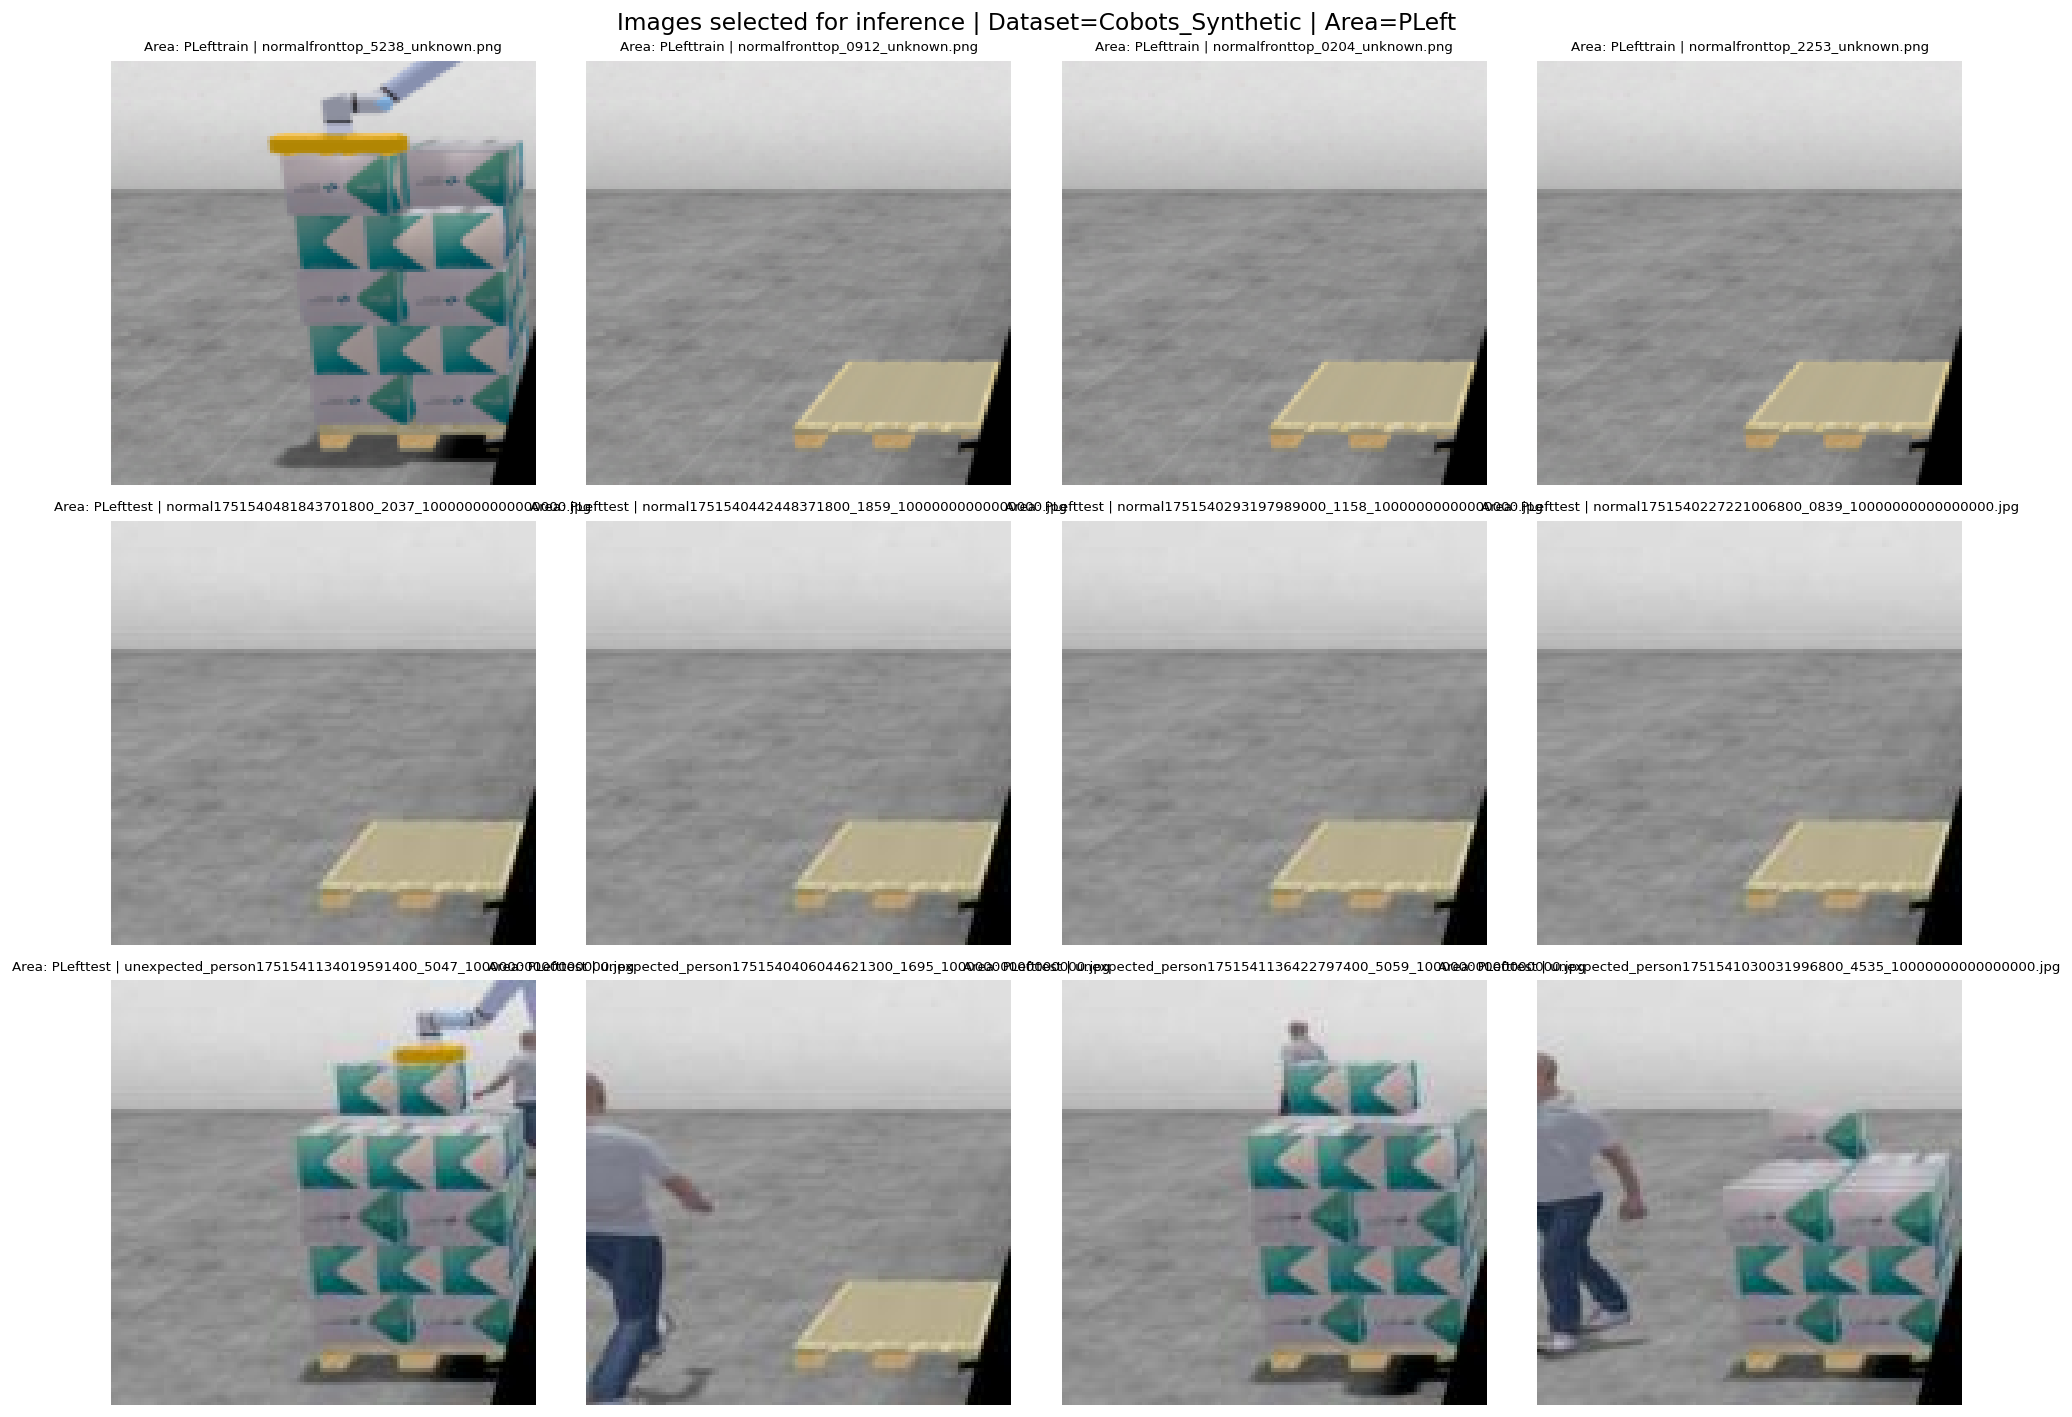

In [10]:
# ============================================================
# Sample collection and preview
# ============================================================
IMG_EXTS = ["*.png", "*.jpg", "*.jpeg", "*.bmp"]


def list_images(root):
    if root is None:
        return []
    root = Path(root)
    files = []
    for ext in IMG_EXTS:
        files.extend(root.rglob(ext))
    return sorted(files)


def pick_samples(files, n):
    files = list(files)
    if len(files) == 0:
        return []
    if len(files) <= n:
        return files
    return random.sample(files, n)


def collect_bound_samples(train_normal_root, test_normal_root, test_anomaly_root):
    train_normal = list_images(train_normal_root)
    test_normal = list_images(test_normal_root)
    test_anomaly = list_images(test_anomaly_root)

    print("=" * 80)
    print("SAMPLE COUNTS")
    print("=" * 80)
    print("Train normal:", len(train_normal), "from", train_normal_root)
    print("Test normal:", len(test_normal), "from", test_normal_root)
    print("Test anomaly:", len(test_anomaly), "from", test_anomaly_root)

    samples = []
    for p in pick_samples(train_normal, N_TRAIN_NORMAL):
        samples.append({"path": p, "split": "train", "label": "normal", "area": CANONICAL_AREA})
    for p in pick_samples(test_normal, N_TEST_NORMAL):
        samples.append({"path": p, "split": "test", "label": "normal", "area": CANONICAL_AREA})
    for p in pick_samples(test_anomaly, N_TEST_ANOMALY):
        samples.append({"path": p, "split": "test", "label": "unexpected_person", "area": CANONICAL_AREA})

    if len(samples) == 0:
        raise RuntimeError("No image samples found. Check dataset paths and extensions.")
    return samples


def show_selected_samples(samples, max_images=12):
    samples = samples[:max_images]
    cols = 4
    rows = int(np.ceil(len(samples) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, s in zip(axes, samples):
        img = Image.open(s["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"Area: {s['area']}{s['split']} | {s['label']}{s['path'].name}", fontsize=8)
        ax.axis("off")

    plt.suptitle(f"Images selected for inference | Dataset={DATASET_NAME} | Area={CANONICAL_AREA}", fontsize=14)
    plt.tight_layout()
    plt.show()


samples = collect_bound_samples(train_normal_root, test_normal_root, test_anomaly_root)
show_selected_samples(samples, max_images=12)

## Import model classes and load checkpoint

In [11]:
# ============================================================
# Import model classes
# ============================================================
def import_model_classes():
    errors = []
    candidates = [
        ("utils_model", ["Encoder", "Decoder", "Discriminator"]),
        ("utils_model_CAD", ["Encoder", "Decoder", "Discriminator"]),
        ("scripts.utils_model", ["Encoder", "Decoder", "Discriminator"]),
        ("models", ["Encoder", "Decoder", "Discriminator"]),
    ]

    for module_name, class_names in candidates:
        try:
            module = __import__(module_name, fromlist=class_names)
            classes = [getattr(module, c) for c in class_names]
            print(f"✓ Imported model classes from {module_name}")
            return classes
        except Exception as e:
            errors.append(f"{module_name}: {repr(e)}")

    raise ImportError("Could not import Encoder/Decoder/Discriminator. Tried:" + "".join(errors))


Encoder, Decoder, Discriminator = import_model_classes()

✓ Imported model classes from utils_model


In [12]:
# ============================================================
# Robust checkpoint loading
# ============================================================
def create_model(cls, latent_dims=None):
    if latent_dims is None:
        return cls()

    attempts = [
        lambda: cls(z_size=latent_dims),
        lambda: cls(latent_dims=latent_dims),
        lambda: cls(latent_dim=latent_dims),
        lambda: cls(latent_dims),
    ]
    last_err = None
    for fn in attempts:
        try:
            return fn()
        except Exception as e:
            last_err = e
    raise last_err


def extract_state_dict(checkpoint, possible_keys):
    for key in possible_keys:
        if key in checkpoint:
            return checkpoint[key]
    raise KeyError(f"None of these keys found in checkpoint: {possible_keys}. Available: {list(checkpoint.keys())}")


def load_vaegan_checkpoint(model_path, latent_dims, device):
    checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
    if not isinstance(checkpoint, dict):
        raise TypeError(f"Expected checkpoint dict, got {type(checkpoint)}")

    print("Checkpoint keys:", list(checkpoint.keys()))

    encoder_sd = extract_state_dict(checkpoint, ["encoder_state_dict", "encoder", "Encoder"])
    decoder_sd = extract_state_dict(checkpoint, ["decoder_state_dict", "decoder", "Decoder", "generator_state_dict", "generator"])

    encoder = create_model(Encoder, latent_dims=latent_dims)
    decoder = create_model(Decoder, latent_dims=latent_dims)

    encoder.load_state_dict(encoder_sd)
    decoder.load_state_dict(decoder_sd)

    discriminator = None
    try:
        discriminator_sd = extract_state_dict(checkpoint, ["discriminator_state_dict", "discriminator", "Discriminator"])
        discriminator = create_model(Discriminator, latent_dims=None)
        discriminator.load_state_dict(discriminator_sd)
    except Exception as e:
        print("⚠️ Discriminator not loaded:", e)

    encoder.to(device).eval()
    decoder.to(device).eval()
    if discriminator is not None:
        discriminator.to(device).eval()

    return encoder, decoder, discriminator, checkpoint


encoder, decoder, discriminator, checkpoint = load_vaegan_checkpoint(MODEL_PATH, LATENT_DIMS, device)
print(f"✓ Loaded model for {CANONICAL_AREA}: {MODEL_PATH.name}")

Checkpoint keys: ['encoder_state_dict', 'decoder_state_dict', 'discriminator_state_dict', 'optimizer_enc_state_dict', 'optimizer_dec_state_dict', 'loss_history']
✓ Loaded model for PLeft: model_PLeft_64.pt


In [13]:
# ============================================================
# Parameter summary and forward sanity check
# ============================================================
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

for name, model in [("Encoder", encoder), ("Decoder", decoder), ("Discriminator", discriminator)]:
    if model is None:
        continue
    total, trainable = count_parameters(model)
    print(f"{name}: total={total:,} | trainable={trainable:,}")

with torch.no_grad():
    dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    mu, logvar = encoder(dummy)
    recon = decoder(mu)

print("Forward test:")
print(" input:", tuple(dummy.shape))
print(" mu:", tuple(mu.shape))
print(" logvar:", tuple(logvar.shape))
print(" recon:", tuple(recon.shape))
print(" recon range:", float(recon.min()), float(recon.max()))

Encoder: total=6,950,976 | trainable=6,950,976
Decoder: total=4,885,955 | trainable=4,885,955
Discriminator: total=8,482,369 | trainable=8,482,369
Forward test:
 input: (1, 3, 128, 128)
 mu: (1, 64)
 logvar: (1, 64)
 recon: (1, 3, 128, 128)
 recon range: -0.5298900008201599 0.2619200050830841


## Real-image reconstruction test

The transform uses `Normalize(0.5, 0.5)` because the VAE-GAN decoder outputs `Tanh`, so the model expects input in `[-1, 1]`. For stable inspection, the latent mean `mu` is used instead of random sampling.

In [14]:
# ============================================================
# Image transform and reconstruction utilities
# ============================================================
model_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


def denorm(x):
    return torch.clamp((x * 0.5) + 0.5, 0, 1)


def load_image_tensor(image_path, device):
    img = Image.open(image_path).convert("RGB")
    x = model_transform(img).unsqueeze(0).to(device)
    return x, img


def reconstruct_tensor(x, encoder, decoder, use_mu=True):
    with torch.no_grad():
        mu, logvar = encoder(x)
        if use_mu:
            z = mu
        else:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            z = mu + eps * std
        recon = decoder(z)
    return recon, mu, logvar


def compute_scores(x, recon):
    diff = torch.abs(x - recon)
    diff_map = diff.mean(dim=1)[0]
    return {
        "mae": diff.mean().item(),
        "mse": torch.mean((x - recon) ** 2).item(),
        "max": diff_map.max().item(),
        "q90": torch.quantile(diff_map.flatten(), 0.90).item(),
        "q95": torch.quantile(diff_map.flatten(), 0.95).item(),
        "q99": torch.quantile(diff_map.flatten(), 0.99).item(),
    }, diff_map

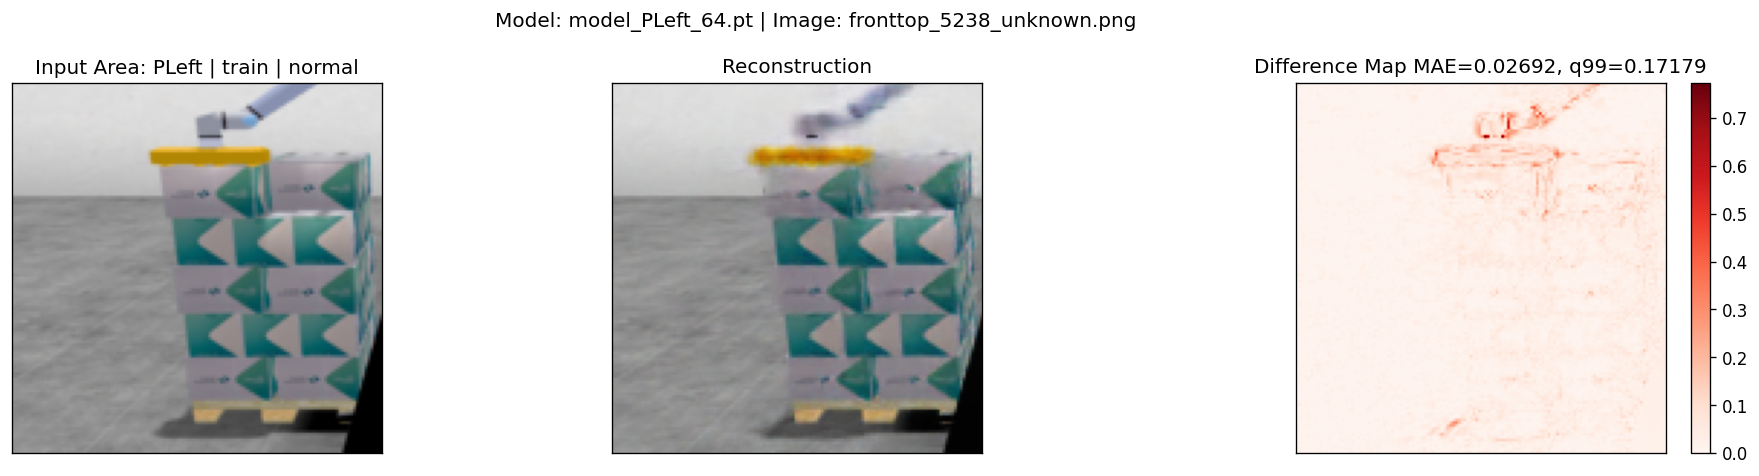

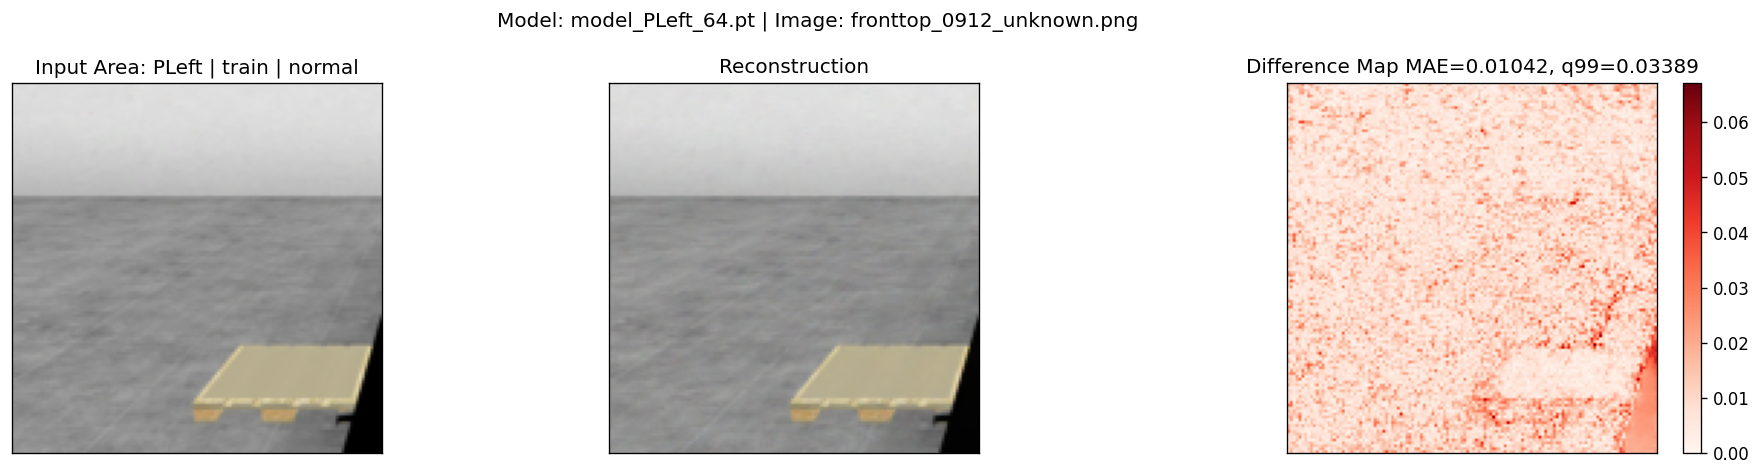

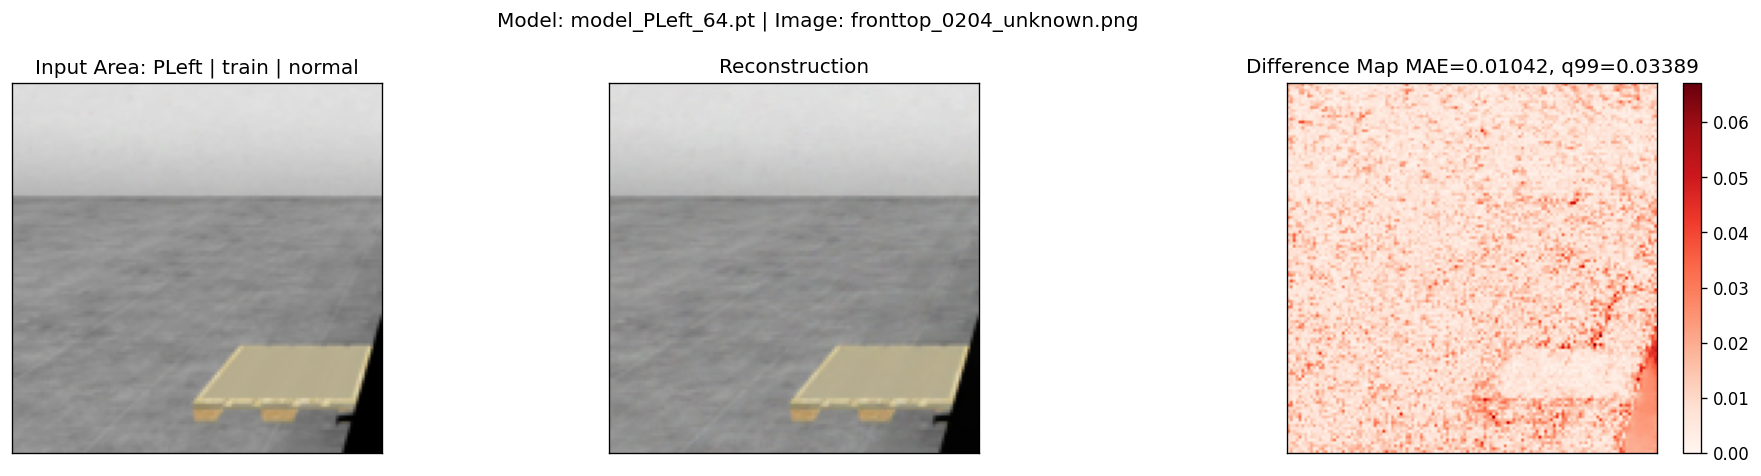

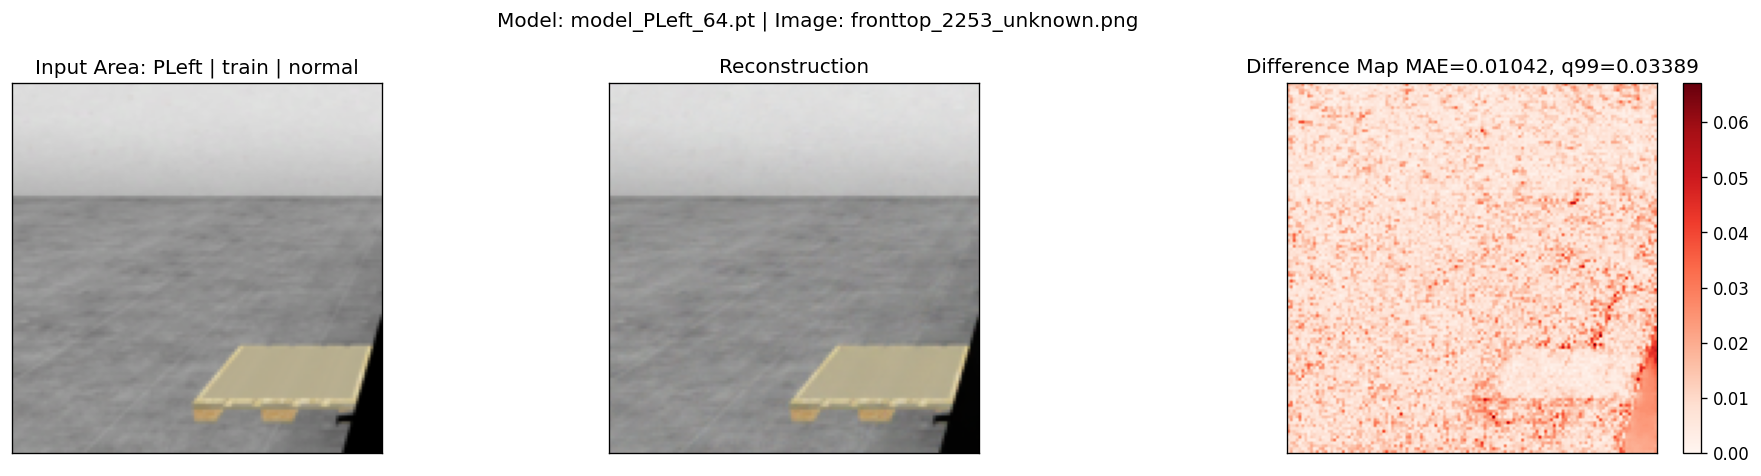

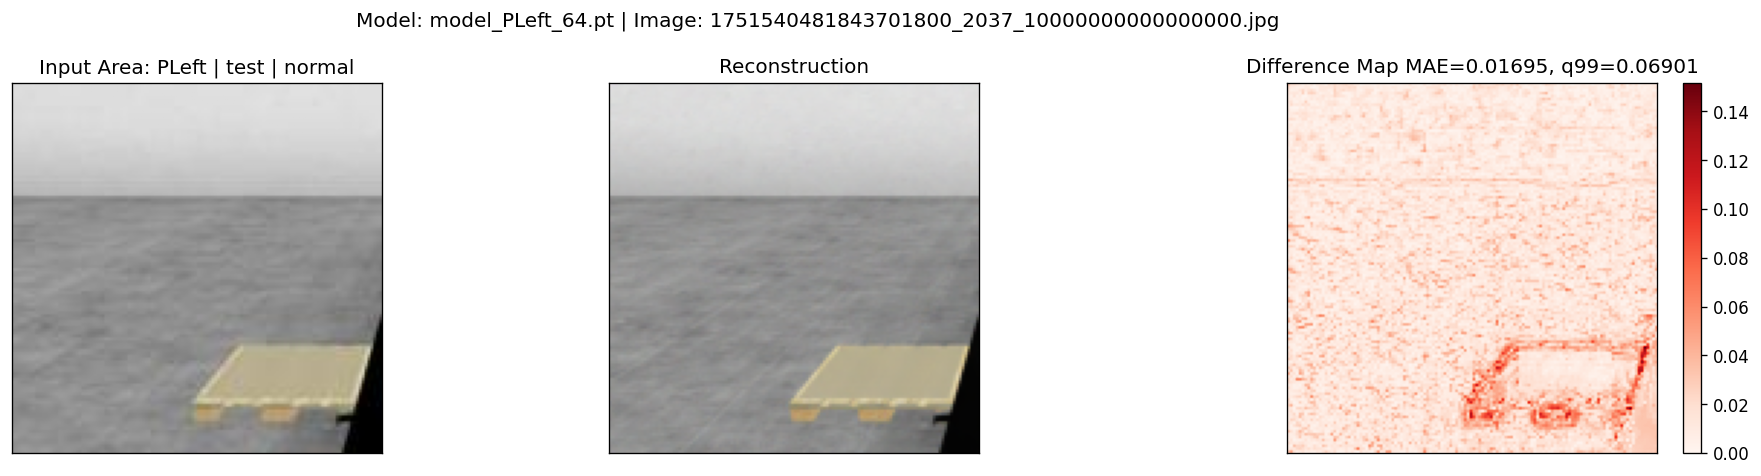

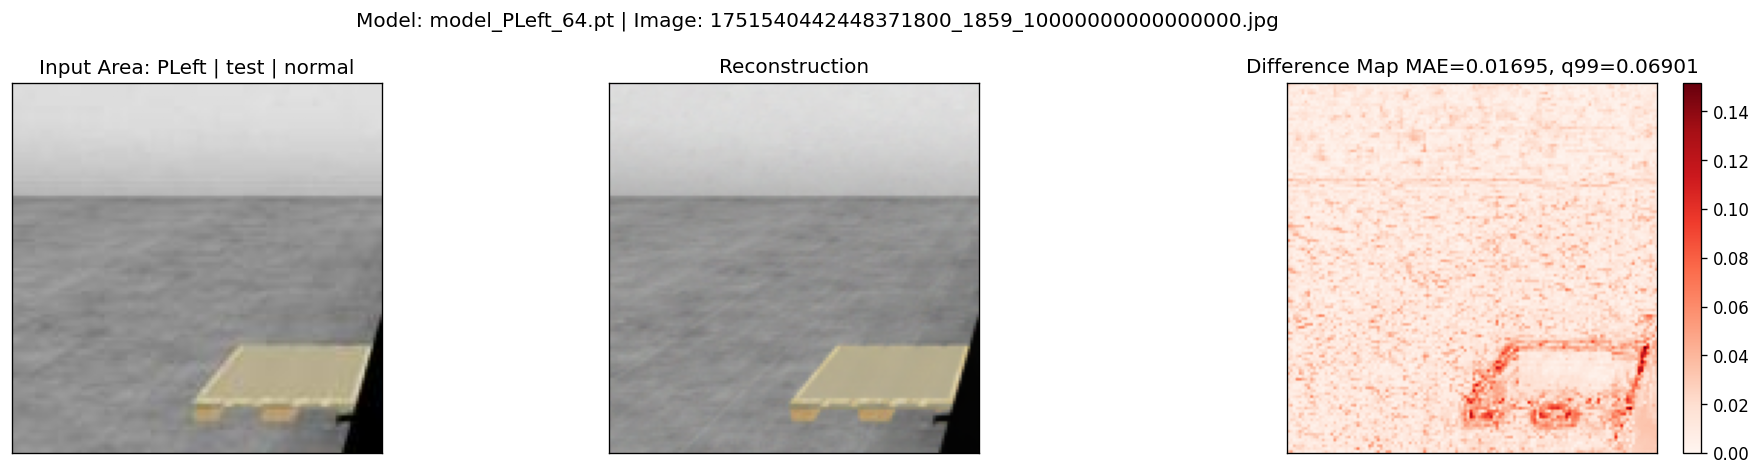

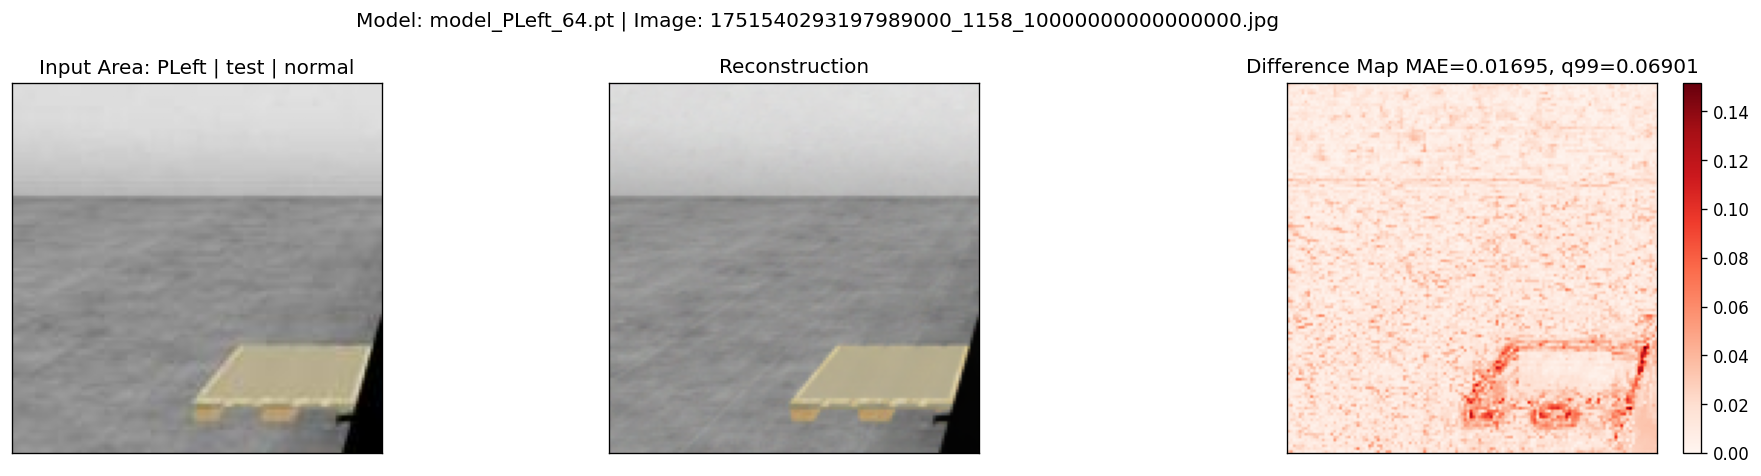

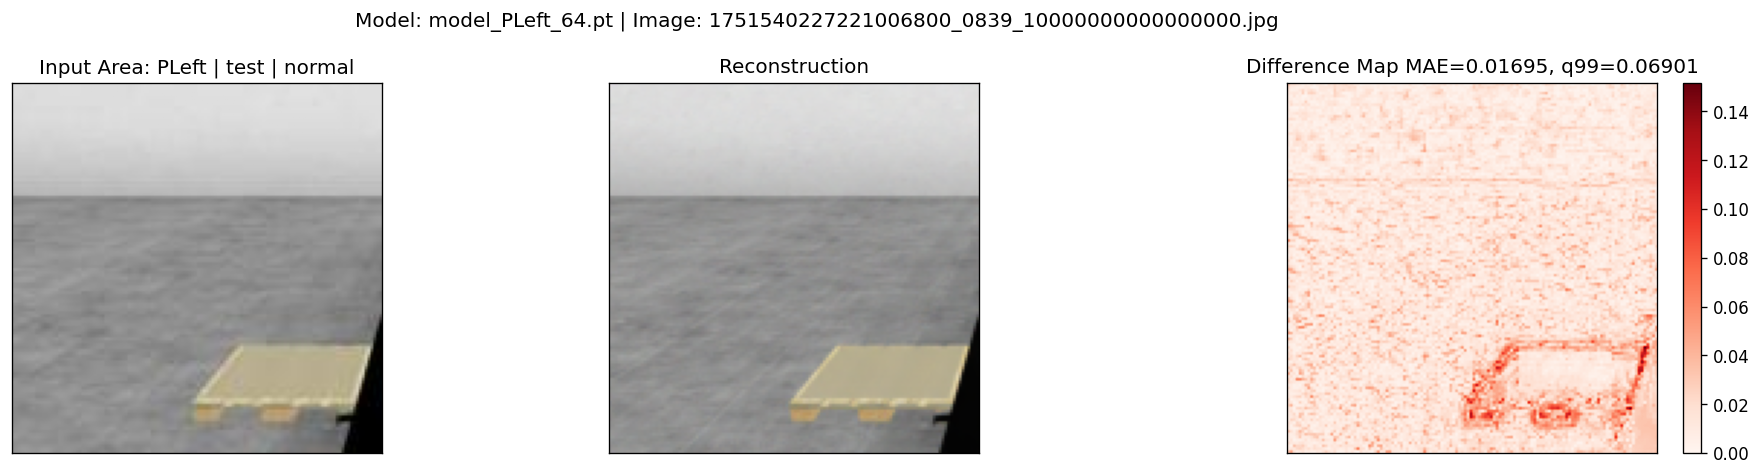

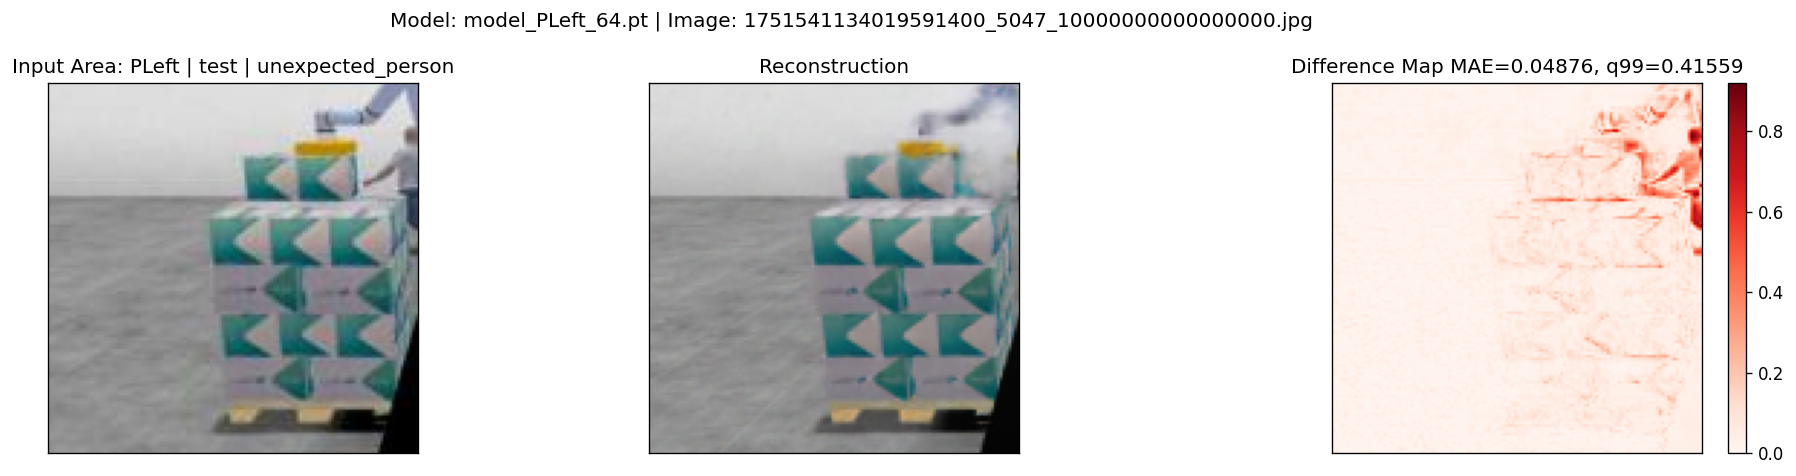

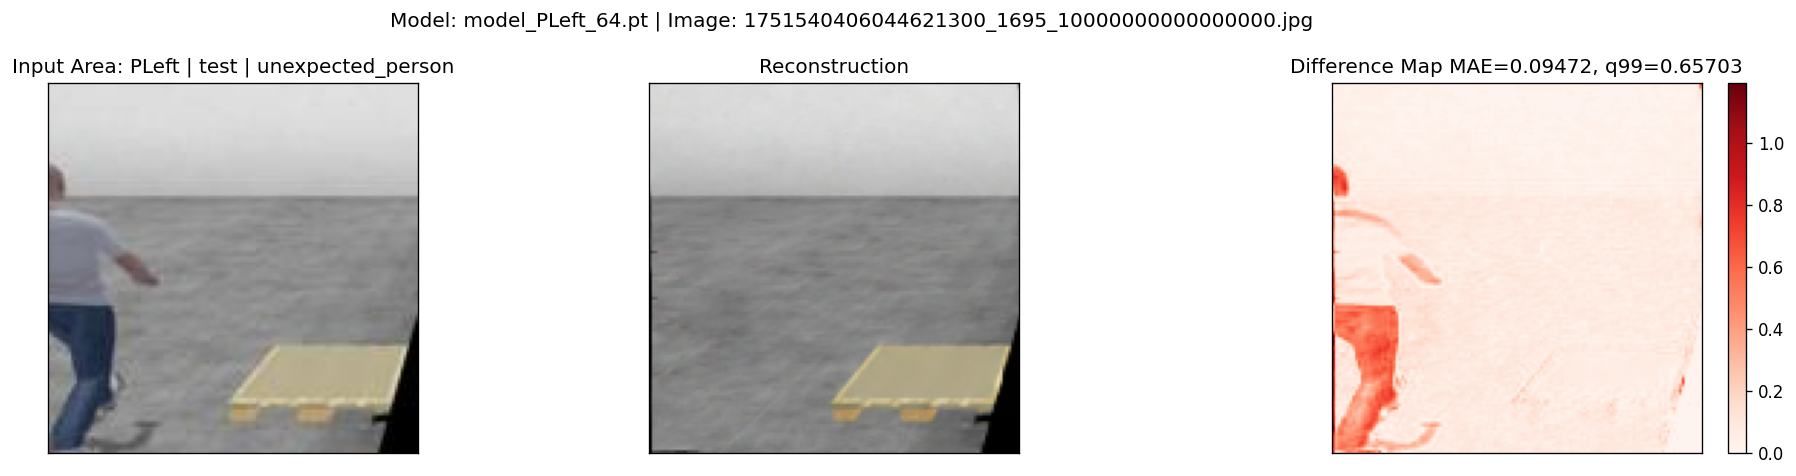

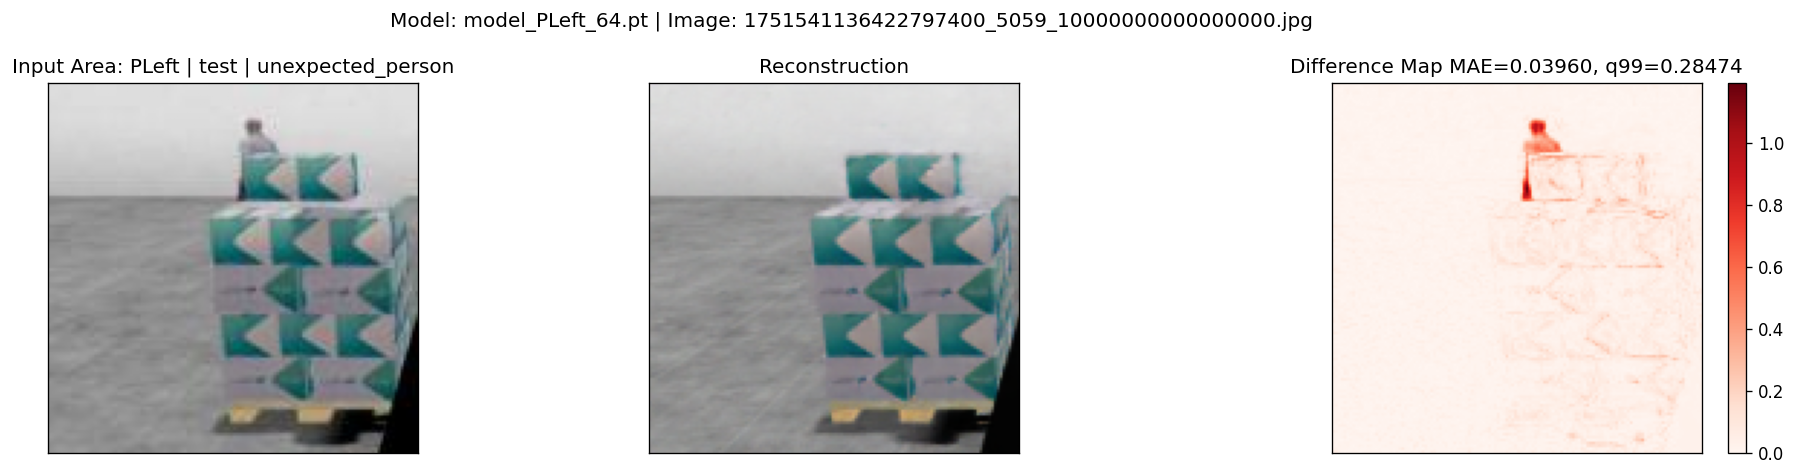

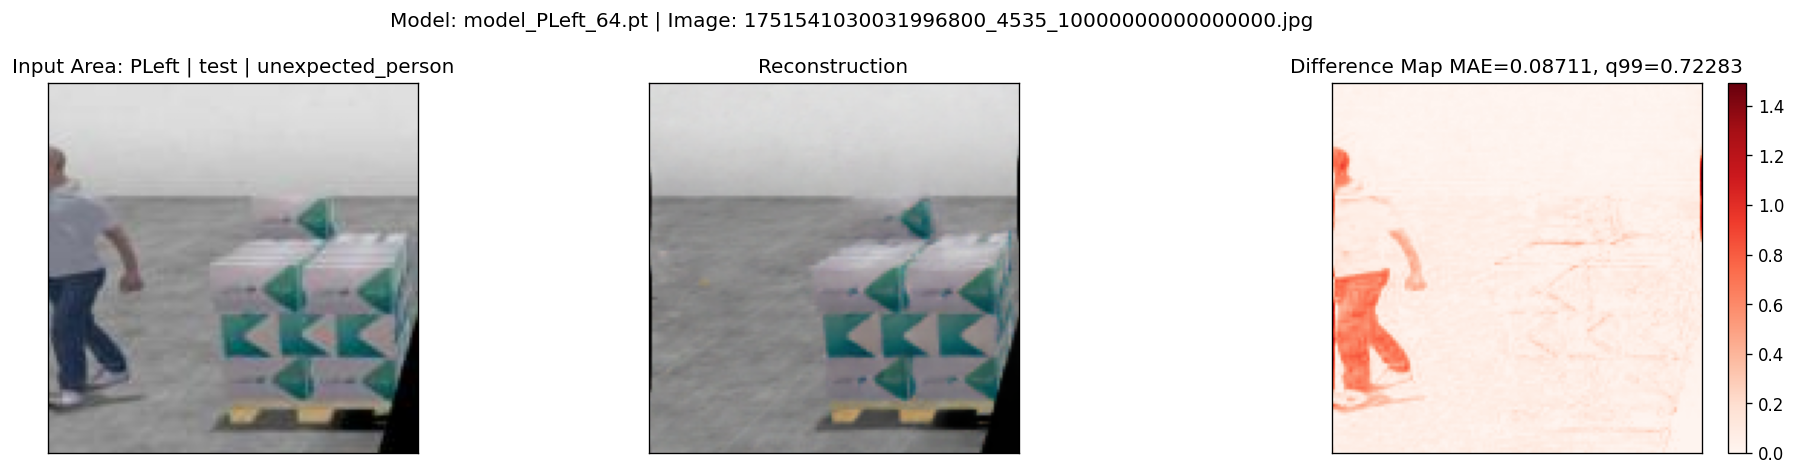

Done. Samples tested: 12


In [19]:
# ============================================================
# Plot reconstruction results
# ============================================================
def plot_reconstruction_sample(sample, encoder, decoder, device, use_mu=True):
    image_path = sample["path"]
    x, _ = load_image_tensor(image_path, device)
    recon, mu, logvar = reconstruct_tensor(x, encoder, decoder, use_mu=use_mu)
    scores, diff_map = compute_scores(x, recon)

    x_vis = denorm(x[0]).detach().cpu().permute(1, 2, 0).numpy()
    recon_vis = denorm(recon[0]).detach().cpu().permute(1, 2, 0).numpy()
    diff_np = diff_map.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].imshow(x_vis)
    axes[0].set_title(f"Input Area: {sample['area']} | {sample['split']} | {sample['label']}")
    # axes[0].axis("off")

    axes[1].imshow(recon_vis)
    axes[1].set_title("Reconstruction")
    # axes[1].axis("off")

    vm = np.max(np.abs(diff_np))  # Cap the max for better visualization
    im = axes[2].imshow(diff_np, cmap="Reds", vmin=0, vmax=vm)
    axes[2].set_title(f"Difference Map MAE={scores['mae']:.5f}, q99={scores['q99']:.5f}")
    
    
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.suptitle(f"Model: {MODEL_PATH.name} | Image: {Path(image_path).name}", fontsize=12)
    plt.tight_layout()
    plt.show()

    row = dict(scores)
    row.update({
        "area": sample["area"],
        "split": sample["split"],
        "label": sample["label"],
        "path": str(image_path),
        "model": MODEL_PATH.name,
    })
    return row


results = []
for sample in samples:
    results.append(plot_reconstruction_sample(sample, encoder, decoder, device, use_mu=True))

print("Done. Samples tested:", len(results))

In [16]:
# ============================================================
# Results table
# ============================================================
try:
    import pandas as pd
    df = pd.DataFrame(results)
    display(df[["area", "split", "label", "mae", "mse", "q90", "q95", "q99", "model", "path"]])
except Exception:
    pprint(results)

,area,split,label,mae,mse,q90,q95,q99,model,path
0,PLeft,train,normal,0.026917,0.002334,0.056962,0.082642,0.171786,model_PLeft_64.pt,D:\DS\AD\Cobots_Synthetic\train\PLeft\normal\f...
1,PLeft,train,normal,0.010419,0.000184,0.019792,0.024114,0.033888,model_PLeft_64.pt,D:\DS\AD\Cobots_Synthetic\train\PLeft\normal\f...
2,PLeft,train,normal,0.010419,0.000184,0.019792,0.024114,0.033888,model_PLeft_64.pt,D:\DS\AD\Cobots_Synthetic\train\PLeft\normal\f...
3,PLeft,train,normal,0.010419,0.000184,0.019792,0.024114,0.033888,model_PLeft_64.pt,D:\DS\AD\Cobots_Synthetic\train\PLeft\normal\f...
4,PLeft,test,normal,0.016953,0.000578,0.032889,0.042240,0.069005,model_PLeft_64.pt,D:\DS\AD\Cobots_Synthetic\test\unexpected_pers...
5,PLeft,test,normal,0.016953,0.000578,0.032889,0.042240,0.069005,model_PLeft_64.pt,D:\DS\AD\Cobots_Synthetic\test\unexpected_pers...
6,PLeft,test,normal,0.016953,0.000578,0.032889,0.042240,0.069005,model_PLeft_64.pt,D:\DS\AD\Cobots_Synthetic\test\unexpected_pers...
7,PLeft,test,normal,0.016953,0.000578,0.032889,0.042240,0.069005,model_PLeft_64.pt,D:\DS\AD\Cobots_Synthetic\test\unexpected_pers...
8,PLeft,test,unexpected_person,0.048762,0.008973,0.104952,0.163243,0.415592,model_PLeft_64.pt,D:\DS\AD\Cobots_Synthetic\test\unexpected_pers...
9,PLeft,test,unexpected_person,0.094720,0.026229,0.140849,0.399713,0.657028,model_PLeft_64.pt,D:\DS\AD\Cobots_Synthetic\test\unexpected_pers...


## Optional: compare score distributions

mae       mse       q95       q99
area  split label                                                    
PLeft test  normal             0.016953  0.000578  0.042240  0.069005
            unexpected_person  0.067546  0.017878  0.275382  0.520047
      train normal             0.014544  0.000721  0.038746  0.068362

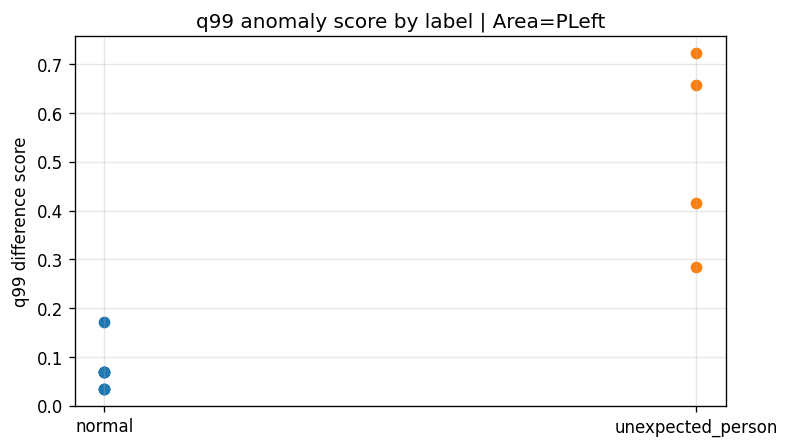

In [17]:
try:
    import pandas as pd
    df = pd.DataFrame(results)
    if not df.empty:
        display(df.groupby(["area", "split", "label"])[["mae", "mse", "q95", "q99"]].mean())

        labels = df["label"].unique().tolist()
        if len(labels) > 1:
            plt.figure(figsize=(7, 4))
            for label in labels:
                vals = df[df["label"] == label]["q99"].values
                plt.scatter([label] * len(vals), vals)
            plt.title(f"q99 anomaly score by label | Area={CANONICAL_AREA}")
            plt.ylabel("q99 difference score")
            plt.grid(True, alpha=0.3)
            plt.show()
except Exception as e:
    print("Could not summarize results:", e)